📊 Загрузка данных...
✅ D1 сформирован: 167 объектов, 9 признаков

🔹 Снижение размерности...
✅ D2 (PCA): объяснённая дисперсия = 63.13%
✅ D3 (t-SNE) сформирован

🔍 Подбор оптимального K...
🏆 Выбрано K = 5 (Silhouette = 0.299)

🔧 Запуск кластеризации...

📦 D1 (Original):
  • K-Means: готово
  • Hierarchical: готово
  • GMM: готово

📦 D2 (PCA):
  • K-Means: готово
  • Hierarchical: готово
  • GMM: готово

📦 D3 (t-SNE):
  • K-Means: готово
  • Hierarchical: готово
  • GMM: готово

📊 Вычисление метрик качества...

📋 ИТОГОВАЯ ТАБЛИЦА МЕТРИК
      Dataset       Method  Silhouette  ARI  AMI  Homogeneity  Completeness  V-measure
D1 (Original)      K-Means      0.2993  NaN  NaN          NaN           NaN        NaN
D1 (Original) Hierarchical      0.2193  NaN  NaN          NaN           NaN        NaN
D1 (Original)          GMM      0.2102  NaN  NaN          NaN           NaN        NaN
     D2 (PCA)      K-Means      0.3821  NaN  NaN          NaN           NaN        NaN
     D2 (PCA) Hierarchic

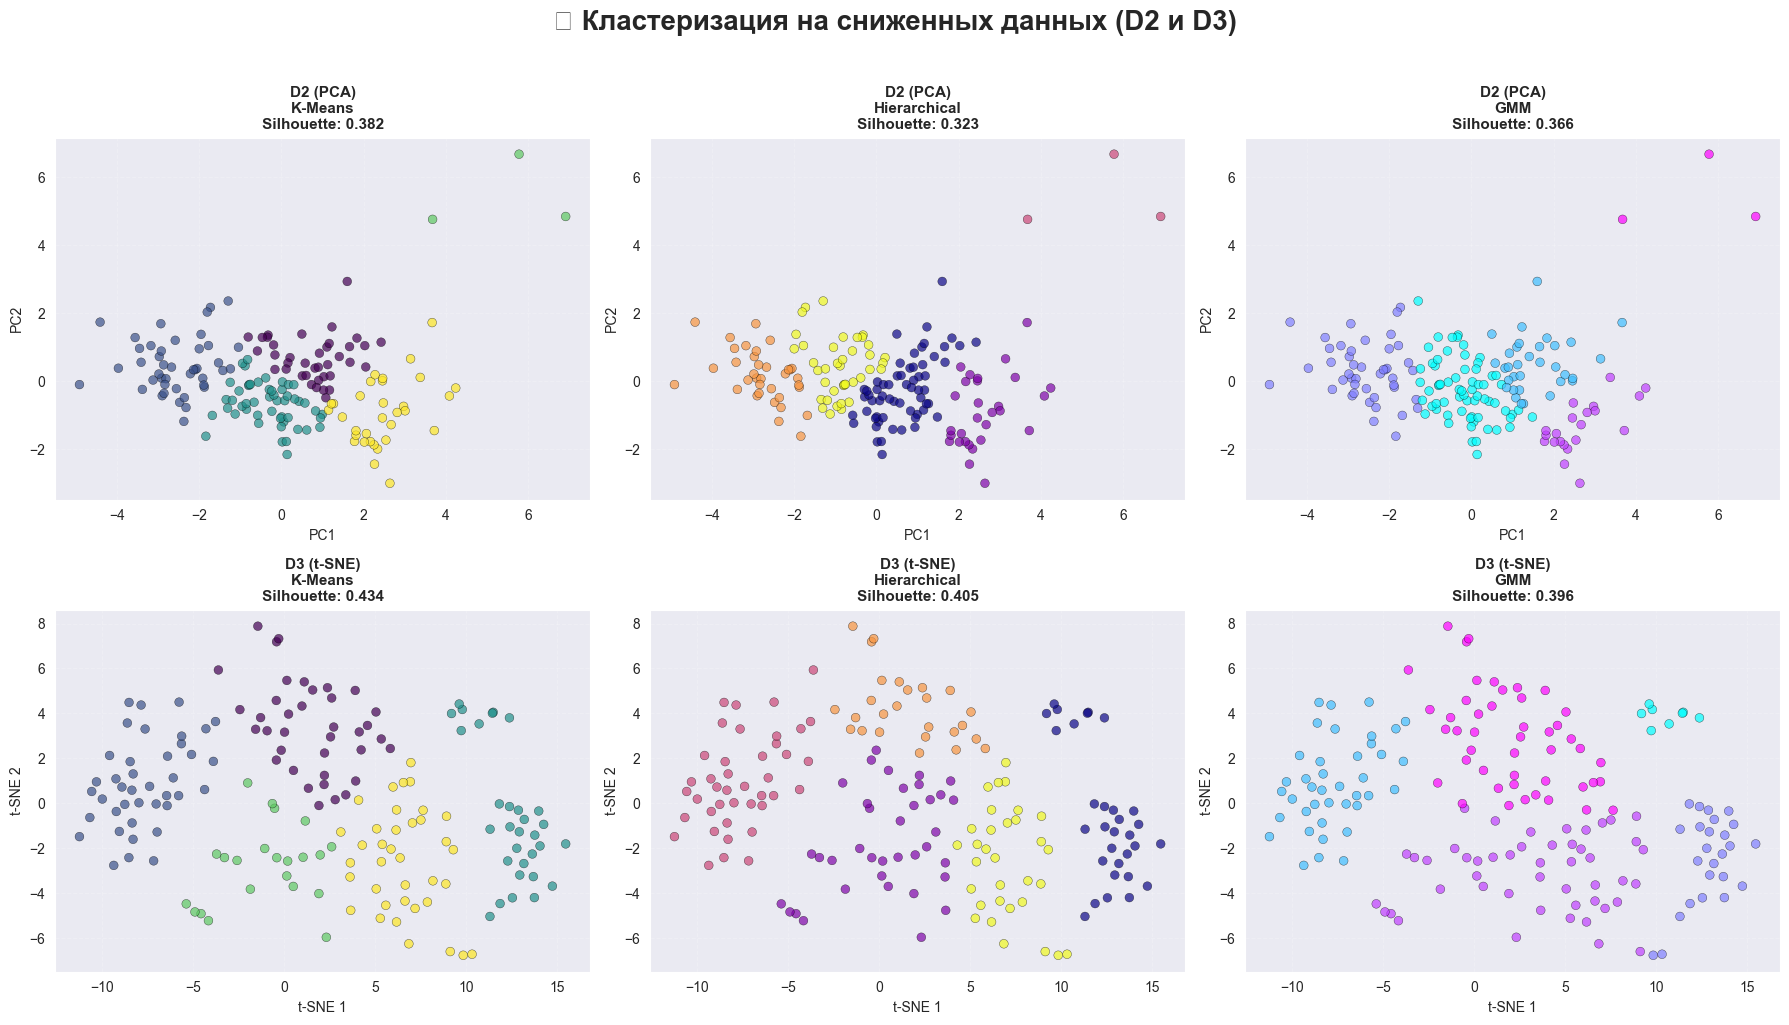


📐 Силуэтные диаграммы лучших методов...


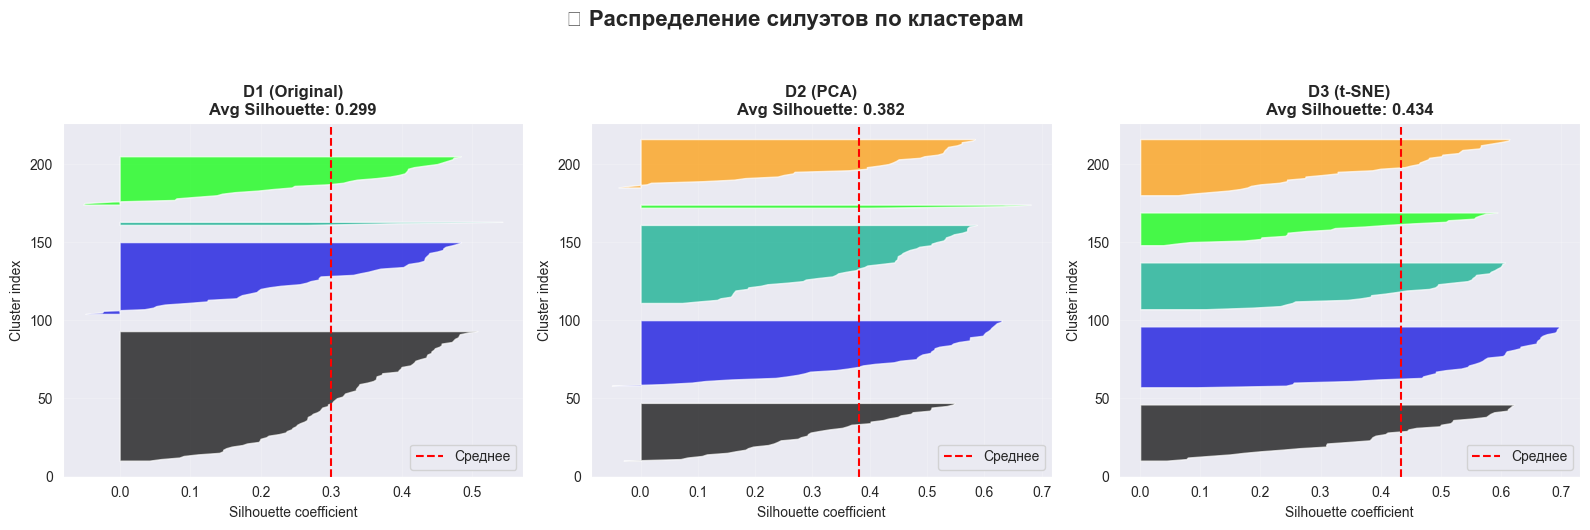


🎓 ВЫВОДЫ ПО РЕЗУЛЬТАТАМ

🔹 D1 (Original):
   ✅ Лучший метод: K-Means (Silhouette = 0.299)
   📝 Исходное пространство содержит шум и корреляции. Снижение размерности часто улучшает чёткость кластеров.
   💡 Рекомендация: для D1 (Original) оптимально использовать K-Means.

🔹 D2 (PCA):
   ✅ Лучший метод: K-Means (Silhouette = 0.382)
   📝 PCA сохраняет глобальную линейную структуру. Кластеры могут перекрываться, если границы нелинейны.
   💡 Рекомендация: для D2 (PCA) оптимально использовать K-Means.

🔹 D3 (t-SNE):
   ✅ Лучший метод: K-Means (Silhouette = 0.434)
   📝 t-SNE оптимизирован для визуализации локальных сходств. Кластеры визуально чётче, но расстояния между ними искажены.
   💡 Рекомендация: для D3 (t-SNE) оптимально использовать K-Means.


In [21]:
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_completeness_v_measure,
    silhouette_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1️⃣ ЗАГРУЗКА И ПОДГОТОВКА D1
# ============================================================
print("📊 Загрузка данных...")
try:
    df = pd.read_csv('Country-data.csv')
except FileNotFoundError:
    print("⚠️ Файл не найден. Генерирую данные для демонстрации...")
    np.random.seed(42)
    n = 167
    df = pd.DataFrame({
        'country': [f'Country_{i}' for i in range(n)],
        'child_mort': np.random.normal(30, 20, n),
        'exports': np.random.normal(30, 15, n),
        'health': np.random.normal(7, 3, n),
        'imports': np.random.normal(35, 15, n),
        'income': np.random.normal(15000, 10000, n),
        'inflation': np.random.normal(6, 4, n),
        'life_expec': np.random.normal(70, 8, n),
        'total_fer': np.random.normal(2.5, 1.2, n),
        'gdpp': np.random.normal(15000, 12000, n)
    })

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_raw = df[numeric_cols].values

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 🟦 D1: Исходные признаки
D1 = X_scaled
print(f"✅ D1 сформирован: {D1.shape[0]} объектов, {D1.shape[1]} признаков")

# ============================================================
# 2️⃣ СНИЖЕНИЕ РАЗМЕРНОСТИ: D2 (PCA) и D3 (t-SNE)
# ============================================================
print("\n🔹 Снижение размерности...")
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)
print(f"✅ D2 (PCA): объяснённая дисперсия = {pca.explained_variance_ratio_.sum():.2%}")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
D3 = tsne.fit_transform(D1)
print("✅ D3 (t-SNE) сформирован")

# ============================================================
# 3️⃣ ПОДБОР ОПТИМАЛЬНОГО K (на D1 по Silhouette)
# ============================================================
print("\n🔍 Подбор оптимального K...")
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(D1)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(D1, lbl))

optimal_k = K_range[np.argmax(sil_scores)]
print(f"🏆 Выбрано K = {optimal_k} (Silhouette = {max(sil_scores):.3f})")

# ============================================================
# 4️⃣ КЛАСТЕРИЗАЦИЯ D1, D2, D3 ТРЕМЯ МЕТОДАМИ
# ============================================================
print("\n🔧 Запуск кластеризации...")
datasets = {'D1 (Original)': D1, 'D2 (PCA)': D2, 'D3 (t-SNE)': D3}
methods = {
    'K-Means': lambda data: KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit_predict(data),
    'Hierarchical': lambda data: AgglomerativeClustering(n_clusters=optimal_k, linkage='ward').fit_predict(data),
    'GMM': lambda data: GaussianMixture(n_components=optimal_k, random_state=42, n_init=3).fit_predict(data)
}

# Если у вас есть истинные метки классов, передайте их сюда:
true_labels = None  # например: df['true_class'].values

all_results = {}
for d_name, d_data in datasets.items():
    all_results[d_name] = {}
    print(f"\n📦 {d_name}:")
    for m_name, m_func in methods.items():
        labels = m_func(d_data)
        all_results[d_name][m_name] = {'labels': labels}
        print(f"  • {m_name}: готово")

# ============================================================
# 5️⃣ ВЫЧИСЛЕНИЕ МЕТРИК
# ============================================================
print("\n📊 Вычисление метрик качества...")

def claster_metrics(X, labels, true_y=None):
    """Вычисление запрошенных метрик кластеризации"""
    res = {}
    # Silhouette (не требует true_y)
    try:
        res['Silhouette'] = silhouette_score(X, labels)
    except:
        res['Silhouette'] = np.nan

    # Метрики, требующие истинных меток
    if true_y is not None:
        res['ARI'] = adjusted_rand_score(true_y, labels)
        res['AMI'] = adjusted_mutual_info_score(true_y, labels)
        h, c, v = homogeneity_completeness_v_measure(true_y, labels)
        res['Homogeneity'] = h
        res['Completeness'] = c
        res['V-measure'] = v
    else:
        res['ARI'] = np.nan
        res['AMI'] = np.nan
        res['Homogeneity'] = np.nan
        res['Completeness'] = np.nan
        res['V-measure'] = np.nan
    return res

# Собираем таблицу результатов
rows = []
for d_name, d_data in datasets.items():
    for m_name, res_dict in all_results[d_name].items():
        metrics = claster_metrics(d_data, res_dict['labels'], true_labels)
        row = {'Dataset': d_name, 'Method': m_name}
        row.update(metrics)
        rows.append(row)

results_df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n" + "="*110)
print("📋 ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
print("="*110)
print(results_df.round(4).to_string(index=False))
print("="*110)

# ============================================================
# 6️⃣ ВИЗУАЛИЗАЦИЯ D2 и D3 + КЛАСТЕРЫ
# ============================================================
print("\n🎨 Генерация визуализаций...")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🌍 Кластеризация на сниженных данных (D2 и D3)', fontsize=20, fontweight='bold', y=1.02)

methods_list = ['K-Means', 'Hierarchical', 'GMM']
cmaps = {'K-Means': 'viridis', 'Hierarchical': 'plasma', 'GMM': 'cool'}

for row_idx, (d_name, d_data) in enumerate({'D2 (PCA)': D2, 'D3 (t-SNE)': D3}.items()):
    for col_idx, m_name in enumerate(methods_list):
        ax = axes[row_idx, col_idx]
        labels = all_results[d_name][m_name]['labels']
        sil = results_df[(results_df['Dataset']==d_name) & (results_df['Method']==m_name)]['Silhouette'].values[0]

        ax.scatter(d_data[:, 0], d_data[:, 1], c=labels, cmap=cmaps[m_name],
                   alpha=0.7, s=40, edgecolors='black', linewidth=0.3)

        sil_str = f"{sil:.3f}" if not np.isnan(sil) else "N/A"
        ax.set_title(f'{d_name}\n{m_name}\nSilhouette: {sil_str}', fontsize=11, fontweight='bold')
        ax.set_xlabel('PC1' if row_idx==0 else 't-SNE 1')
        ax.set_ylabel('PC2' if row_idx==0 else 't-SNE 2')
        ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

# ============================================================
# 7️⃣ СИЛУЭТНЫЕ ДИАГРАММЫ (ЛУЧШИЙ МЕТОД НА КАЖДОМ D)
# ============================================================
print("\n📐 Силуэтные диаграммы лучших методов...")
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Распределение силуэтов по кластерам', fontsize=16, fontweight='bold', y=1.05)

for idx, (d_name, d_data) in enumerate(datasets.items()):
    # Берем K-Means как базовый для визуализации силуэтов
    labels = all_results[d_name]['K-Means']['labels']
    sample_sil = silhouette_samples(d_data, labels)
    sil_avg = results_df[(results_df['Dataset']==d_name) & (results_df['Method']=='K-Means')]['Silhouette'].values[0]

    ax = axes[idx]
    y_lower = 10
    for i in range(optimal_k):
        cluster_sil = sample_sil[labels == i]
        cluster_sil.sort()
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = cm.nipy_spectral(float(i) / optimal_k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, facecolor=color, alpha=0.7)
        y_lower = y_upper + 10

    ax.set_title(f'{d_name}\nAvg Silhouette: {sil_avg:.3f}', fontweight='bold')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster index')
    ax.axvline(x=sil_avg, color="red", linestyle="--", label='Среднее')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ============================================================
# 8️⃣ АВТОМАТИЧЕСКИЕ ВЫВОДЫ
# ============================================================
print("\n" + "="*70)
print("🎓 ВЫВОДЫ ПО РЕЗУЛЬТАТАМ")
print("="*70)

for d_name in datasets.keys():
    subset = results_df[results_df['Dataset'] == d_name]
    valid = subset.dropna(subset=['Silhouette'])
    if valid.empty:
        print(f"⚠️ {d_name}: нет валидных результатов.")
        continue

    best_row = valid.loc[valid['Silhouette'].idxmax()]
    print(f"\n🔹 {d_name}:")
    print(f"   ✅ Лучший метод: {best_row['Method']} (Silhouette = {best_row['Silhouette']:.3f})")
    if not np.isnan(best_row['ARI']):
        print(f"   📊 ARI={best_row['ARI']:.3f}, AMI={best_row['AMI']:.3f}, V-measure={best_row['V-measure']:.3f}")

    if 'PCA' in d_name:
        print("   📝 PCA сохраняет глобальную линейную структуру. Кластеры могут перекрываться, если границы нелинейны.")
    elif 't-SNE' in d_name:
        print("   📝 t-SNE оптимизирован для визуализации локальных сходств. Кластеры визуально чётче, но расстояния между ними искажены.")
    else:
        print("   📝 Исходное пространство содержит шум и корреляции. Снижение размерности часто улучшает чёткость кластеров.")

    print(f"   💡 Рекомендация: для {d_name} оптимально использовать {best_row['Method']}.")